In [1]:
import os
import math
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("wangszhi/xau-1day-gold-datasets")

# print("Path to dataset files:", path)

In [3]:
# =========================
# 1) Load data
# =========================
path = "/kaggle/input/datasets/wangszhi/xau-1day-gold-datasets/XAU_1d_data.csv"
if not os.path.exists(path):
    path = "XAU_1d_data.csv"  # fallback nếu bạn chạy local

df = pd.read_csv(path, sep=";")
print(df.head())
print(df.columns)

df["Date"] = pd.to_datetime(df["Date"], format="%Y.%m.%d %H:%M", errors="coerce")

numeric_cols = ["Open", "High", "Low", "Close", "Volume"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna().sort_values("Date").reset_index(drop=True)
print("Rows after basic cleaning:", len(df))

               Date   Open   High    Low  Close  Volume
0  2004.06.11 00:00  384.0  384.8  382.8  384.1     272
1  2004.06.14 00:00  384.3  385.8  381.8  382.8    1902
2  2004.06.15 00:00  382.8  388.8  381.1  388.6    1951
3  2004.06.16 00:00  387.1  389.8  382.6  383.8    2014
4  2004.06.17 00:00  383.6  389.3  383.0  387.6    1568
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')
Rows after basic cleaning: 5516


In [4]:
# =========================
# 2) Feature engineering
#    Target = % change of Close from yesterday to today
# =========================
def build_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()

    # Input features
    data["body_pct"] = (data["Close"] - data["Open"]) / data["Open"]
    data["range_pct"] = (data["High"] - data["Low"]) / data["Open"]
    data["close_return_1"] = data["Close"].pct_change()
    data["open_gap_pct"] = (data["Open"] - data["Close"].shift(1)) / data["Close"].shift(1)
    data["volume_return_1"] = data["Volume"].pct_change()

    # Target: daily % change of close vs previous close
    data["target_pct"] = data["Close"].pct_change()

    # Clean inf / NaN
    data = data.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    return data

df_feat = build_features(df)

feature_cols = [
    "Open", "High", "Low", "Close", "Volume",
    "body_pct", "range_pct", "close_return_1", "open_gap_pct", "volume_return_1"
]
target_col = "target_pct"

print("Feature columns:", feature_cols)
print("Prepared rows:", len(df_feat))
print(df_feat[["Date", "Close", "target_pct"]].head(10))

Feature columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'body_pct', 'range_pct', 'close_return_1', 'open_gap_pct', 'volume_return_1']
Prepared rows: 5515
        Date  Close  target_pct
0 2004-06-14  382.8   -0.003385
1 2004-06-15  388.6    0.015152
2 2004-06-16  383.8   -0.012352
3 2004-06-17  387.6    0.009901
4 2004-06-18  394.3    0.017286
5 2004-06-21  393.1   -0.003043
6 2004-06-22  394.1    0.002544
7 2004-06-23  395.6    0.003806
8 2004-06-24  401.1    0.013903
9 2004-06-25  401.1    0.000000


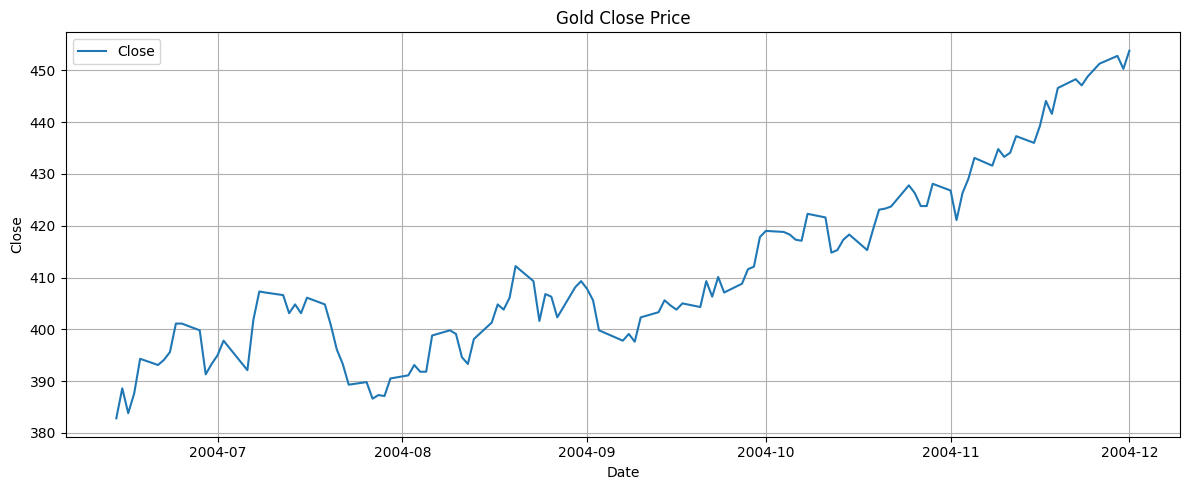

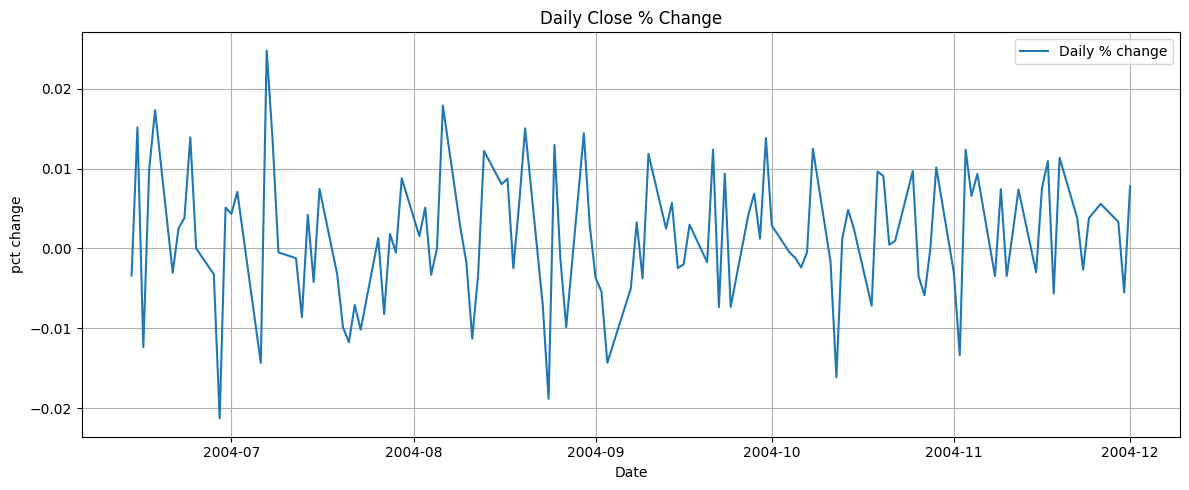

In [5]:
# =========================
# 3) Quick visualization
# =========================
plt.figure(figsize=(12, 5))
plt.plot(df_feat["Date"].iloc[:120], df_feat["Close"].iloc[:120], label="Close")
plt.title("Gold Close Price")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df_feat["Date"].iloc[:120], df_feat["target_pct"].iloc[:120], label="Daily % change")
plt.title("Daily Close % Change")
plt.xlabel("Date")
plt.ylabel("pct change")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# =========================
# 4) Chronological split + scaling
# =========================
lookback = 7
horizon = 1  # predict the next day
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15
assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9
n_rows = len(df_feat)
all_sample_starts = np.arange(0, n_rows - lookback)  # target index = start + lookback
target_indices = all_sample_starts + lookback

train_target_end = int(n_rows * train_ratio)
val_target_end = int(n_rows * (train_ratio + val_ratio))

train_starts = all_sample_starts[target_indices < train_target_end]
val_starts = all_sample_starts[(target_indices >= train_target_end) & (target_indices < val_target_end)]
test_starts = all_sample_starts[target_indices >= val_target_end]
print(f"Total rows: {n_rows}")
print(f"Train samples: {len(train_starts)}")
print(f"Val samples:   {len(val_starts)}")
print(f"Test samples:  {len(test_starts)}")

# Fit scaler only on the training period to avoid leakage
train_feature_rows = df_feat.iloc[:train_target_end][feature_cols].values.astype(np.float32)
feature_mean = train_feature_rows.mean(axis=0)
feature_std = train_feature_rows.std(axis=0)
feature_std[feature_std == 0] = 1.0

all_features = df_feat[feature_cols].values.astype(np.float32)
all_features = (all_features - feature_mean) / feature_std

all_target_pct = df_feat[target_col].values.astype(np.float32)
all_close = df_feat["Close"].values.astype(np.float32)
all_dates = df_feat["Date"].values

print("Feature mean shape:", feature_mean.shape)
print("Feature std shape:", feature_std.shape)

Total rows: 5515
Train samples: 3853
Val samples:   827
Test samples:  828
Feature mean shape: (10,)
Feature std shape: (10,)


In [7]:
# =========================
# 5) Dataset
# =========================
class GoldWindowDataset(Dataset):
    def __init__(self, features, target_pct, close_prices, dates, sample_starts, lookback=7):
        self.features = features.astype(np.float32)
        self.target_pct = target_pct.astype(np.float32)
        self.close_prices = close_prices.astype(np.float32)
        self.dates = dates
        self.sample_starts = np.asarray(sample_starts, dtype=np.int64)
        self.lookback = lookback

    def __len__(self):
        return len(self.sample_starts)

    def __getitem__(self, idx):
        start = self.sample_starts[idx]
        end = start + self.lookback  # target index = next day after the window

        x = self.features[start:end]                # [lookback, num_features]
        y = self.target_pct[end]                   # pct change on the target day
        base_close = self.close_prices[end - 1]    # close of the last input day
        true_close = self.close_prices[end]        # actual close on the target day
        target_date = self.dates[end]

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor([y], dtype=torch.float32),
            torch.tensor([base_close], dtype=torch.float32),
            torch.tensor([true_close], dtype=torch.float32),
            torch.tensor(end, dtype=torch.long),
        )

train_dataset = GoldWindowDataset(all_features, all_target_pct, all_close, all_dates, train_starts, lookback=lookback)
val_dataset = GoldWindowDataset(all_features, all_target_pct, all_close, all_dates, val_starts, lookback=lookback)
test_dataset = GoldWindowDataset(all_features, all_target_pct, all_close, all_dates, test_starts, lookback=lookback)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, drop_last=False)

print("Example batch shapes:")
xb, yb, baseb, trueb, idxb = next(iter(train_loader))
print(xb.shape, yb.shape, baseb.shape, trueb.shape, idxb.shape)

Example batch shapes:
torch.Size([64, 7, 10]) torch.Size([64, 1]) torch.Size([64, 1]) torch.Size([64, 1]) torch.Size([64])


In [8]:
# =========================
# 6) GRU + temporal attention model
# =========================
class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.score = nn.Linear(hidden_dim, 1)

    def forward(self, gru_out):
        # gru_out: [B, T, H]
        attn_logits = self.score(gru_out).squeeze(-1)  # [B, T]
        attn_weights = torch.softmax(attn_logits, dim=1)  # [B, T]
        context = torch.sum(gru_out * attn_weights.unsqueeze(-1), dim=1)  # [B, H]
        return context, attn_weights

class GRUAttentionModel(nn.Module):
    def __init__(self, input_size, hidden_dim=64, num_layers=1, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.attn = TemporalAttention(hidden_dim)
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        gru_out, _ = self.gru(x)            # [B, T, H]
        context, attn_weights = self.attn(gru_out)
        out = self.head(context)            # [B, 1]
        return out, attn_weights

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = GRUAttentionModel(
    input_size=len(feature_cols),
    hidden_dim=64,
    num_layers=1,
    dropout=0.15,
).to(device)

criterion = nn.SmoothL1Loss()   # stable for percentage targets
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

print(model)

Device: cuda
GRUAttentionModel(
  (gru): GRU(10, 64, batch_first=True)
  (attn): TemporalAttention(
    (score): Linear(in_features=64, out_features=1, bias=True)
  )
  (head): Sequential(
    (0): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [9]:
# =========================
# 7) Train / evaluate
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_count = 0

    with torch.no_grad():
        for x, y, *_ in loader:
            x = x.to(device)
            y = y.to(device)
            pred, _ = model(x)
            loss = criterion(pred, y)

            bs = x.size(0)
            total_loss += loss.item() * bs
            total_count += bs

    return total_loss / max(total_count, 1)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_count = 0

    for x, y, *_ in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        pred, _ = model(x)
        loss = criterion(pred, y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_count += bs

    return total_loss / max(total_count, 1)

num_epochs = 100
patience = 8
best_val_loss = float("inf")
best_state = None
bad_epochs = 0

train_losses = []
val_losses = []

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch:02d}/{num_epochs}] | train={train_loss:.6f} | val={val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("Early stopping.")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Loaded best model with val loss = {best_val_loss:.6f}")

Epoch [01/100] | train=0.003421 | val=0.000082
Epoch [02/100] | train=0.000301 | val=0.000061
Epoch [03/100] | train=0.000149 | val=0.000056
Epoch [04/100] | train=0.000111 | val=0.000064
Epoch [05/100] | train=0.000091 | val=0.000051
Epoch [06/100] | train=0.000083 | val=0.000054
Epoch [07/100] | train=0.000076 | val=0.000052
Epoch [08/100] | train=0.000073 | val=0.000050
Epoch [09/100] | train=0.000067 | val=0.000049
Epoch [10/100] | train=0.000067 | val=0.000049
Epoch [11/100] | train=0.000065 | val=0.000049
Epoch [12/100] | train=0.000064 | val=0.000049
Epoch [13/100] | train=0.000063 | val=0.000049
Epoch [14/100] | train=0.000062 | val=0.000049
Epoch [15/100] | train=0.000061 | val=0.000049
Epoch [16/100] | train=0.000061 | val=0.000051
Epoch [17/100] | train=0.000060 | val=0.000054
Epoch [18/100] | train=0.000060 | val=0.000052
Early stopping.
Loaded best model with val loss = 0.000049


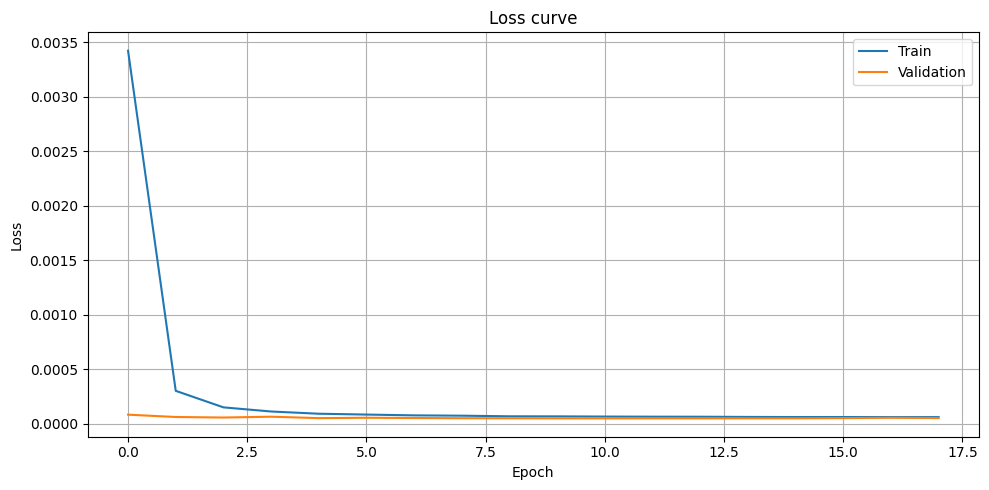

In [10]:
# =========================
# 8) Loss curve
# =========================
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.title("Loss curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# =========================
# 9) Prediction: percentage -> next close
# =========================
def predict(model, loader, device):
    model.eval()
    all_pred_pct = []
    all_true_pct = []
    all_base_close = []
    all_true_close = []
    all_target_idx = []

    with torch.no_grad():
        for x, y, base_close, true_close, target_idx in loader:
            x = x.to(device)
            pred_pct, _ = model(x)

            all_pred_pct.append(pred_pct.cpu().numpy())
            all_true_pct.append(y.numpy())
            all_base_close.append(base_close.numpy())
            all_true_close.append(true_close.numpy())
            all_target_idx.append(target_idx.numpy())

    pred_pct = np.concatenate(all_pred_pct, axis=0).reshape(-1)
    true_pct = np.concatenate(all_true_pct, axis=0).reshape(-1)
    base_close = np.concatenate(all_base_close, axis=0).reshape(-1)
    true_close = np.concatenate(all_true_close, axis=0).reshape(-1)
    target_idx = np.concatenate(all_target_idx, axis=0).reshape(-1)

    # Reconstruct next-day close from predicted pct change
    pred_close = base_close * (1.0 + pred_pct)
    true_close_from_pct = base_close * (1.0 + true_pct)

    return {
        "pred_pct": pred_pct,
        "true_pct": true_pct,
        "base_close": base_close,
        "pred_close": pred_close,
        "true_close": true_close,
        "true_close_from_pct": true_close_from_pct,
        "target_idx": target_idx,
    }

test_out = predict(model, test_loader, device)

print("Test samples:", len(test_out["pred_close"]))
print("First 5 predicted pct:", test_out["pred_pct"][:5])
print("First 5 predicted close:", test_out["pred_close"][:5])

Test samples: 828
First 5 predicted pct: [-0.00174836 -0.00133427 -0.00048517 -0.00077119  0.00022433]
First 5 predicted close: [1694.3923 1662.3391 1674.1973 1674.4177 1665.1335]


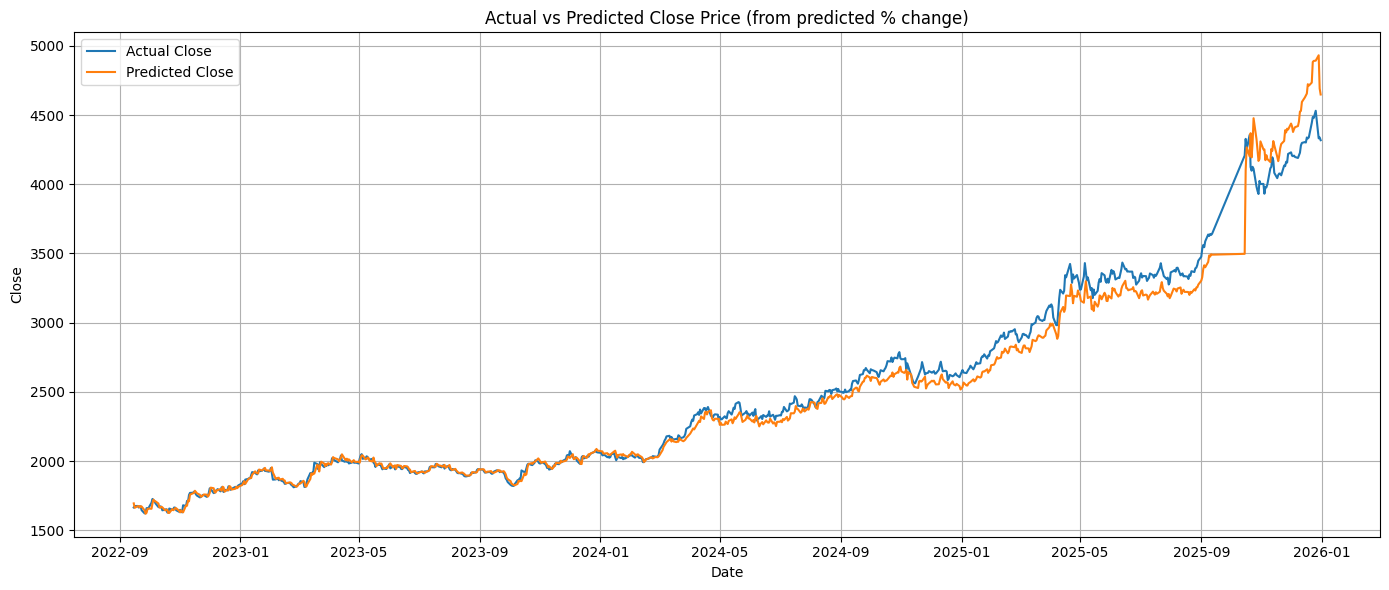

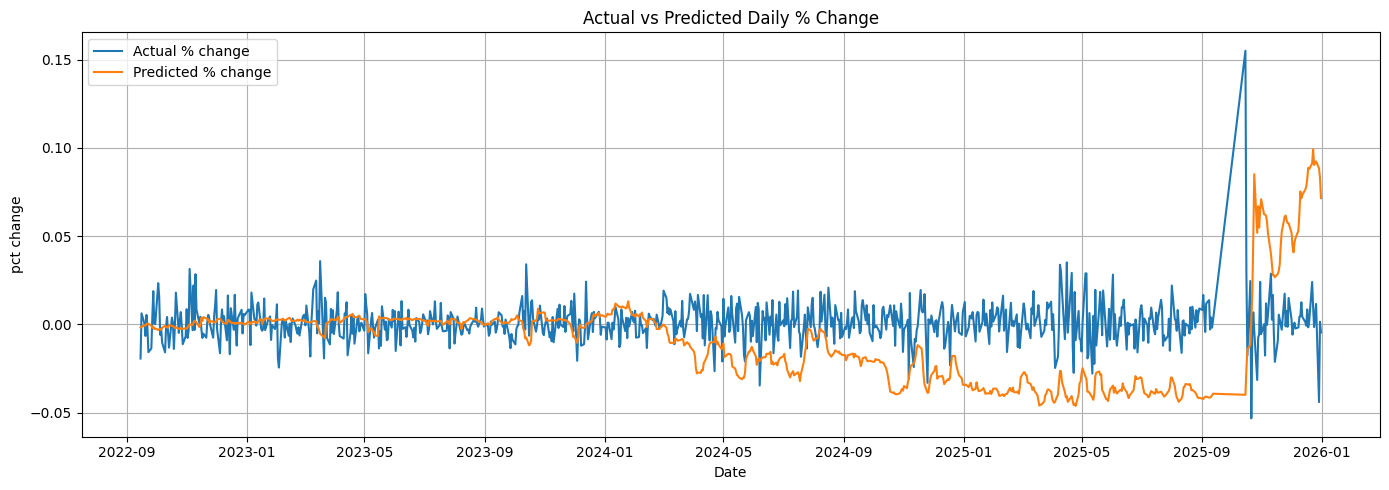

In [12]:
# =========================
# 10) Plot actual vs predicted close
# =========================
target_dates = pd.to_datetime(all_dates[test_out["target_idx"]])

plt.figure(figsize=(14, 6))
plt.plot(target_dates, test_out["true_close"], label="Actual Close")
plt.plot(target_dates, test_out["pred_close"], label="Predicted Close")
plt.title("Actual vs Predicted Close Price (from predicted % change)")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(target_dates, test_out["true_pct"], label="Actual % change")
plt.plot(target_dates, test_out["pred_pct"], label="Predicted % change")
plt.title("Actual vs Predicted Daily % Change")
plt.xlabel("Date")
plt.ylabel("pct change")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# =========================
# 11) Optional: show sample prediction table
# =========================
result_df = pd.DataFrame({
    "Date": target_dates,
    "BaseClose": test_out["base_close"],
    "TruePct": test_out["true_pct"],
    "PredPct": test_out["pred_pct"],
    "TrueClose": test_out["true_close"],
    "PredClose": test_out["pred_close"],
})

print(result_df.head(20))

         Date    BaseClose   TruePct   PredPct    TrueClose    PredClose
0  2022-09-15  1697.359985 -0.019324 -0.001748  1664.560059  1694.392334
1  2022-09-16  1664.560059  0.006278 -0.001334  1675.010010  1662.339111
2  2022-09-19  1675.010010  0.000418 -0.000485  1675.709961  1674.197266
3  2022-09-20  1675.709961 -0.006535 -0.000771  1664.760010  1674.417725
4  2022-09-21  1664.760010  0.005388  0.000224  1673.729980  1665.133545
5  2022-09-22  1673.729980 -0.001535  0.000434  1671.160034  1674.456665
6  2022-09-23  1671.160034 -0.015732  0.000364  1644.869995  1671.768433
7  2022-09-26  1644.869995 -0.013661 -0.000704  1622.400024  1643.711304
8  2022-09-27  1622.400024  0.004167 -0.002009  1629.160034  1619.140869
9  2022-09-28  1629.160034  0.018856 -0.001265  1659.880005  1627.099731
10 2022-09-29  1659.880005  0.000386 -0.002573  1660.520020  1655.609009
11 2022-09-30  1660.520020  0.000163 -0.002291  1660.790039  1656.715088
12 2022-10-03  1660.790039  0.023380 -0.003153  169